## Notebook 2: Differential Expression Analysis

This notebook is the second step and a separate branch in our biomarker discovery pipeline. The goal is to take the filtered raw count data from Notebook 1 and perform a differential expression analysis to identify genes that are significantly up- or down-regulated between different clinical subtypes.

We will use the `inmoose` library, which provides the functionality of the well-established `edgeR` package from R, to conduct this analysis.

---

## Data Source

The primary input for this notebook is the cleaned and filtered raw count data that was generated and exported at the end of the previous notebook (`01_RNA_Seq_Preprocessing_and_QC.ipynb`).

* **Input File**: `filtered_raw_counts.tsv`
* **Description**: The file contains raw integer counts for 17,560 genes across 2,913 samples, with uninformative and low-expression genes already removed.

---

### Installing the Required Library: inmoose

Before we begin our analysis, we first need to install the inmoose library. This is the specialised Python package we will use to perform the differential expression analysis.

We use the `--user` flag to install the package in the current user's local directory, which avoids modifying system-wide Python installations.

In [28]:
# pip install inmoose --user

In [29]:
# Verify that inmoose is installed correctly and check its version details.

# !pip show inmoose

In [30]:
# import numpy as np
# # print(np.__version__)

### Import requried libraries

In [31]:
# Core libraries for data handling and numerical operations ---
import os
import pandas as pd
import numpy as np

# Libraries for data visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns

# Library for creating statistical design matrices ---
from patsy import dmatrix

# Library for statistical multiple testing correction ---
from statsmodels.stats.multitest import multipletests

# Specific functions for Differential Expression Analysis from inmoose
import inmoose
# from inmoose.deseq2 import DESeq
from inmoose.edgepy import estimateGLMCommonDisp, estimateGLMTagwiseDisp, glmFit, glmLRT

print("inmoose is working ✅")

inmoose is working ✅


### Exploring `inmoose` Documentation

To explore the available functions within the `inmoose.edgepy` module, we can use the built-in `help()` function. This command displays the documentation for the module directly in the notebook, providing a quick reference for the tools we will be using.

In [32]:
# help(inmoose.edgepy)

### Loading the Raw Count Data

This cell loads our filtered gene count data, which will be used for the differential expression analysis.

**Important**: The input file for this step must contain **raw, un-normalised integer counts**. Do not use data that has already been normalised (e.g., TMM or log-transformed data).

Differential expression tools like `edgeR` have their own specific methods for normalisation and require raw counts to ensure the statistical analysis is accurate.

In [33]:
# Load the data
counts_df = pd.read_csv("filtered_raw_counts.tsv", sep='\t', index_col=0)

In [34]:
# Display the shape and a preview to confirm it's loaded correctly
print(f"Loaded filtered dataFrame shape: {counts_df.shape}")
print("\nPreview of the loaded data:")
print(counts_df.head(1))

Loaded filtered dataFrame shape: (16374, 3207)

Preview of the loaded data:
      S000001  S000002  S000003  S000006  S000008  S000011  S000012  S000013  \
X                                                                              
A1BG      412      106      158      104      145      202      289       23   

      S000014  S000015  ...  S006771  S006775  S006776  S006777  S006778  \
X                       ...                                                
A1BG      316      200  ...      278      200      339      157      930   

      S006780  S006781  S006782  S006783  S006786  
X                                                  
A1BG      833      457      298      241      533  

[1 rows x 3207 columns]


### Loading the Metadata

To perform a differential expression analysis, we first need to load the clinical metadata. This file contains the essential information that allows us to define the sample groups we want to compare.

For example, we can use columns from this metadata file, such as `'pam50 subtype'` or `'er status'` to split our patient samples into distinct groups. The differential expression analysis will then identify the genes that are statistically different between these groups.

In [35]:
meta_df = pd.read_csv("GSE202203_clean_metadata_final.csv")
print(f"Loaded meta_df shape: {meta_df.shape}")
print("\nPreview of the loaded data:")
meta_df.head()

Loaded meta_df shape: (2913, 24)

Preview of the loaded data:


,Sample ID,scanb external id,age at diagnosis,tumor size,lymph node group,lymph node status,er status,pgr status,her2 status,ki67 status,...,endocrine treated,chemo treated,overall survival days,overall survival years,overall survival event,relapse free interval days,relapse free interval years,relapse free interval event,esr1 expression: log2(tpm+0.1),esr2 expression: log2(tpm+0.1)
0,S000001,Q009061.C009086.S000001.l.r.m.c.lib.g.k2.a,85,13.0,N0,NodeNegative,1.0,1.0,0.0,NaN,...,1.0,0.0,3187.0,8.725530,0.0,387.0,1.059548,0.0,8.396473,-3.321928
1,S000002,Q009043.C009085.S000002.l.r.m.c.lib.g2.k2.a,66,16.0,N0,NodeNegative,0.0,0.0,0.0,NaN,...,0.0,1.0,3192.0,8.739220,0.0,413.0,1.130732,0.0,3.913672,-3.321928
2,S000003,Q009039.C009084.S000003.l.r.m2.c.lib.g.k2.a,63,32.0,N3,4toX,NaN,NaN,NaN,NaN,...,0.0,0.0,785.0,2.149213,1.0,719.0,1.968515,0.0,3.226214,-2.581884
3,S000006,Q009032.C009081.S000006.l.r.lib.g.k2.a,60,18.0,N0,NodeNegative,1.0,0.0,0.0,NaN,...,1.0,1.0,875.0,2.395619,1.0,682.0,1.867214,0.0,0.696891,-2.043983
4,S000011,Q009057.C009076.S000011.l.r.m.c.lib.g.k2.a,76,18.0,N1,1to3,1.0,1.0,0.0,NaN,...,1.0,0.0,3186.0,8.722793,0.0,435.0,1.190965,0.0,6.407396,-2.498252


### Aligning Count Data and Metadata

To ensure data integrity, our count matrix and metadata table must be synchronised. The following function handles this alignment by:
1.  Identifying the set of samples common to both DataFrames.
2.  Filtering both tables to retain only this common set.

This produces two fully aligned DataFrames, which is needed for the analysis.

In [36]:
def align_dataframes(counts_df, meta_df):
    """
    Aligns a count matrix and a metadata DataFrame to keep only common samples.

    Args:
        counts_df (pd.DataFrame): DataFrame with genes as rows and samples as columns.
        meta_df (pd.DataFrame): DataFrame with sample information.

    Returns:
        tuple: A tuple containing the aligned counts DataFrame and the aligned metadata DataFrame.
    """
    # Find the common samples between the counts columns and metadata index/column
    # This handles cases where the sample ID is either an index or a column in meta_df
    if 'Sample ID' in meta_df.columns:
        meta_samples = set(meta_df['Sample ID'])
    else:
        meta_samples = set(meta_df.index)
        
    count_samples = set(counts_df.columns)
    
    common_samples = list(count_samples & meta_samples)
    
    # Filter both DataFrames to keep only the common samples
    aligned_counts = counts_df[common_samples]
    
    if 'Sample ID' in meta_df.columns:
        aligned_meta = meta_df[meta_df['Sample ID'].isin(common_samples)].set_index('Sample ID')
    else:
        aligned_meta = meta_df.loc[common_samples]

    # Final sanity check
    if aligned_counts.shape[1] != aligned_meta.shape[0]:
        raise ValueError("Error: Alignment failed. Sample numbers do not match.")
        
    print(f"Alignment complete. Found {len(common_samples)} common samples.")
    
    return aligned_counts, aligned_meta

In [37]:
# 'counts_df' and 'meta_df' are the original, unaligned DataFrames
counts_aligned, meta_aligned = align_dataframes(counts_df, meta_df)

# get aligned DataFrames
print(f"\nAligned counts shape: {counts_aligned.shape}")
print(f"Aligned metadata shape: {meta_aligned.shape}")

Alignment complete. Found 2913 common samples.

Aligned counts shape: (16374, 2913)
Aligned metadata shape: (2913, 23)


A quick check on avaialable columns in our metadata

In [38]:
meta_aligned.columns

Index(['scanb external id', 'age at diagnosis', 'tumor size',
       'lymph node group', 'lymph node status', 'er status', 'pgr status',
       'her2 status', 'ki67 status', 'nhg', 'pam50 subtype', 'clinical groups',
       'histopathological type', 'endocrine treated', 'chemo treated',
       'overall survival days', 'overall survival years',
       'overall survival event', 'relapse free interval days',
       'relapse free interval years', 'relapse free interval event',
       'esr1 expression: log2(tpm+0.1)', 'esr2 expression: log2(tpm+0.1)'],
      dtype='object')

### Defining the Experimental Design: Luminal A vs. Basal

To find a set of potential prognostic biomarkers, we compare groups with distinct biological characteristics. For this analysis, we decided to use the **PAM50 molecular subtype** to define our comparison groups. The PAM50 classification is a standard in breast cancer research that categorises tumours into subtypes with different prognoses and treatment responses.

We will focus on a direct comparison between two of the most distinct subtypes:

* **Luminal A (LumA)**: This is the most common subtype, which is typically hormone-receptor-positive and has a relatively good prognosis.
* **Basal-like (Basal)**: This subtype is considered to be aggressive, and is also linked to triple-negative breast cancer (TNBC), which is considered to be highly aggressive and worst in terms of prognosis.

So, if we pick these two groups, we are able to work with a high-contrast group for the Differential Expression analysis that is well-suited for identifying genes strongly associated with tumour aggressiveness.

**Further Reading**: For a detailed overview of the prognostic significance of different breast cancer subtypes, see this article: [Molecular Breast Cancer Subtypes: A Review of the Last Decade](https://pmc.ncbi.nlm.nih.gov/articles/PMC4127612/).

In [39]:
meta_aligned['pam50 subtype'].value_counts()

pam50 subtype
LumA            1398
LumB             818
Basal            288
HER2             251
Normal            99
Unclassified      59
Name: count, dtype: int64

In [40]:
# Filtering metadata to include only LumA and Basal
subtype_to_compare = ['LumA', 'Basal']
meta_subset = meta_aligned[meta_aligned['pam50 subtype'].isin(subtype_to_compare)].copy()

# Create a new column 'condition' for DEA (required by inmoose)
meta_subset['condition'] = meta_subset['pam50 subtype']

# Sanity check
print(meta_subset['condition'].value_counts())
print(meta_subset.shape)

condition
LumA     1398
Basal     288
Name: count, dtype: int64
(1686, 24)


### Final Synchronisation of Count Data

In the previous step, we created a metadata table, `meta_subset`, that contains *only* the 'Luminal A' and 'Basal' samples we want to compare.

This final step is to filter our main `counts_df` DataFrame to match it. The code below selects only the columns from our count data that correspond to the samples in `meta_subset`. This ensures our gene expression matrix is perfectly synchronised with our experimental design, which a final check before running the analysis.

In [41]:
# Subset counts_df to match the filtered metadata
counts_subset = counts_df[meta_subset.index]

# Sanity check
print(f"counts subset shape: {counts_subset.shape} (rows x columns)") # Expect (16374, 1686)
print(f"Meta subset shape: {meta_subset.shape} (rows x columns)")
print(counts_subset.columns[:5])   # Should match sample IDs in meta_subset.index

counts subset shape: (16374, 1686) (rows x columns)
Meta subset shape: (1686, 24) (rows x columns)
Index(['S000001', 'S000002', 'S000006', 'S000011', 'S000012'], dtype='object')


### **Optional**: Running the Analysis on a Data Subset

The main differential expression analysis on the full dataset can take several minutes depending on your computer's performance. The code block below provides an option to run the same pipeline on a smaller, more manageable subset of the data.

This is useful for two reasons:
1.  **Quick Test Run**: You can run it first to quickly verify that the entire code pipeline works without errors without having to wait the entire duration of longer minutes.
2.  **Performance Workaround**: If your system is too slow to handle the full dataset, you can use this subset to get a result more quickly.

You can easily adjust the number of random samples and the number of top-expressed genes to include in this test run.

In [42]:
# # 1. Randomly select 'n' samples, I have selected 800 by default:
# subset_samples = np.random.choice(counts_subset.columns, 800, replace=False)

# # 2. Keep top 'n' most expressed genes, I have kept the number as 3000 for default value
# top_genes = counts_subset.sum(axis=1).sort_values(ascending=False).head(3000).index

# # 3. Subset counts and metadata
# test_counts = counts_subset.loc[top_genes, subset_samples]
# test_meta = meta_subset.loc[subset_samples]

# # 4. Update group labels
# test_group_labels = (test_meta['condition'] == 'Basal').astype(int).values.reshape(-1, 1)

# # Step 5: Proceed with the exact same edgepy pipeline using:
# # - counts_matrix = test_counts.values
# # - design = test_group_labels

### Running the Differential Expression Analysis using edgeR function

    It should take around 5m to 10m for the edgeR process depending on your system.

In [43]:
# Steps to implement: 

# 1. Build the design matrix from your filtered metadata for the comparison
# This uses 'meta_subset', which has 1,686 samples
design = dmatrix("~ condition", data=meta_subset, return_type='dataframe')

# 2. We are using the full filtered counts matrix for the analysis
# Note:This is 'counts_subset', which has 16,374 genes and 1,686 samples
counts_matrix = counts_subset

print("Estimating dispersion on the full dataset...")
disp_common = estimateGLMCommonDisp(counts_matrix.values, design=design.values)
disp_tagwise = estimateGLMTagwiseDisp(
    counts_matrix.values, design=design.values, dispersion=disp_common
)

print("\nFitting the GLM...")
fit = glmFit(counts_matrix, design=design, dispersion=disp_tagwise)

print("\nRunning the Likelihood Ratio Test...")
lrt = glmLRT(fit)

print("\nAnalysis complete on the full dataset.")

Estimating dispersion on the full dataset...

Fitting the GLM...

Running the Likelihood Ratio Test...

Analysis complete on the full dataset.


### Extracting and Filtering the Results

In [44]:
# Extract results from the Likelihood Ratio Test object
results_df = lrt.copy()

# Re-attach gene names from the full counts matrix ('counts_subset')
results_df.index = counts_subset.index

# Sort by p-value to see the most significant genes first
results_df = results_df.sort_values("pvalue")

# Preview the top 20 most significant genes
print("Top 20 differentially expressed genes from the full analysis:\n")
print(results_df.head(20))

Top 20 differentially expressed genes from the full analysis:

         log2FoldChange     lfcSE    logCPM         stat  pvalue
X                                                               
ANXA9          3.850449  0.003655  4.881777  1600.141121     0.0
ABAT           3.413274  0.002729  6.305095  1770.913727     0.0
C6orf15       -5.947493  0.018758  2.085959  1882.117988     0.0
C5AR2          2.783648  0.002341  4.187570  1519.164331     0.0
CDC123        -0.976427  0.000447  5.746475  1700.351825     0.0
HRCT1         -3.305149  0.005621  2.529139  1925.358247     0.0
NUP93         -0.990121  0.000396  5.253558  1975.473248     0.0
ABTB2         -2.108565  0.002415  3.494013  1673.203391     0.0
ANP32E        -1.612641  0.001184  5.065957  1896.283667     0.0
PRR11         -2.430566  0.001756  2.543919  3136.571499     0.0
PRR4          -3.584413  0.004650  2.968230  2768.120332     0.0
PRR15          3.767374  0.002717  5.147584  2084.906847     0.0
LAMP3         -2.634513  0.

In [45]:
# # Save the full results to a new CSV file with a meaninful file name
results_df.to_csv("DEA_results_edgeR_LumA_vs_Basal_full.csv")

## Preparing Data for the Volcano Plot

Before creating the volcano plot, we need to add two new columns to our results table. The following code calculates the y-axis position (`-log10(p_adj)`) and assigns a colour category ('Up-regulated', 'Down-regulated', or 'Not Significant') to each gene. This is a necessary data preparation step for the visualisation.

In [46]:
# 1. Add adjusted p-values to your results
# This corrects for the fact that we are testing thousands of genes at once
results_df['p_adj'] = multipletests(results_df['pvalue'], method='fdr_bh')[1]

# 2. Define your significance thresholds

# A common choice is an adjusted p-value < 0.05 and a log2 fold change > 1 (for up) or < -1 (for down)
P_ADJ_THRESHOLD = 0.05
LOG_FC_THRESHOLD = 1.0

# 3. Create a column to easily identify significant genes
results_df['significant'] = (results_df['p_adj'] < P_ADJ_THRESHOLD) & \
                            (np.abs(results_df['log2FoldChange']) > LOG_FC_THRESHOLD)

In [47]:
# Create a new column for the -log10 adjusted p-value for the y-axis
# -log10 transformation is used to convert the tiny p-values into large, positive numbers so that it is easier to visualise.
results_df['-log10(p_adj)'] = -np.log10(results_df['p_adj'])

# Create a column to colour points by (Up-regulated, Down-regulated, Not significant)
# Default to 'Not Significant'
results_df['colour'] = 'Not Significant'
# Colour up-regulated genes
results_df.loc[(results_df['significant']) & (results_df['log2FoldChange'] > 0), 'colour'] = 'Up-regulated'
# Colour down-regulated genes
results_df.loc[(results_df['significant']) & (results_df['log2FoldChange'] < 0), 'colour'] = 'Down-regulated'

### The Volcano Plot

The volcano plot below provides a complete summary of our differential expression analysis. Each point is a single gene, plotted by its statistical significance (y-axis) versus its fold change between the two groups (x-axis).

This allows us to quickly see the most significant up-regulated genes (red) and down-regulated genes (blue).

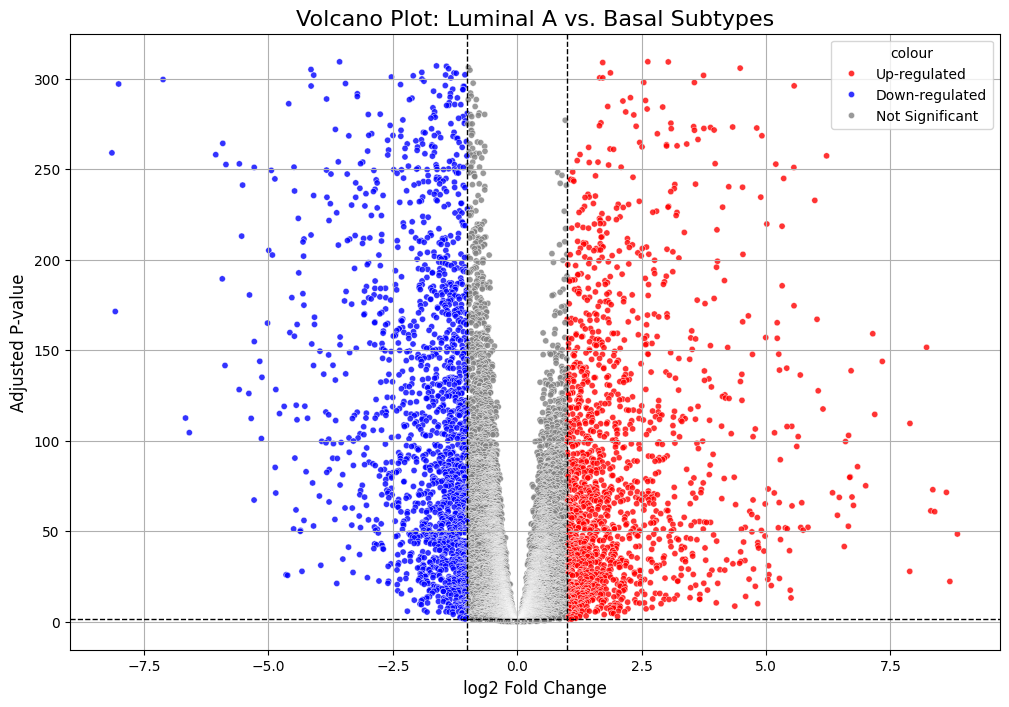

In [48]:
# plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=results_df,
    x='log2FoldChange',
    y='-log10(p_adj)',
    hue='colour', # Colour points by the new column
    palette={'Up-regulated': 'red', 'Down-regulated': 'blue', 'Not Significant': 'grey'},
    s=20, # Marker size
    alpha=0.8
)

# lines for the thresholds
plt.axvline(x=LOG_FC_THRESHOLD, color='black', linestyle='--', linewidth=1)
plt.axvline(x=-LOG_FC_THRESHOLD, color='black', linestyle='--', linewidth=1)
plt.axhline(y=-np.log10(P_ADJ_THRESHOLD), color='black', linestyle='--', linewidth=1)

plt.title('Volcano Plot: Luminal A vs. Basal Subtypes', fontsize=16)
plt.xlabel('log2 Fold Change', fontsize=12)
plt.ylabel('Adjusted P-value', fontsize=12)
plt.grid(True)
plt.show()

### Results: Volcano Plot

This volcano plot provides a complete summary of the differential expression analysis between the **Luminal A** and **Basal** cancer subtypes. Each point on the plot represents one of the ~16,000 genes we tested.

- **Red Points**: These are the genes that are significantly **up-regulated**, meaning they are more highly expressed in the 'Basal' subtype.
- **Blue Points**: These are the genes that are significantly **down-regulated**, meaning they are less expressed in the 'Basal' subtype.
- **Grey Points**: These are genes whose expression was not significantly different between the two groups.